# GW peak signal, $N_s=32$, varying the wall velocity $v_w$ ($\log_{10}$ axes)

Peak GW signal $(f_{\rm peak},\,h^2\Omega_{\rm peak})$ for fixed wall velocities
$v_w \in \{v_J,\,1.0,\,0.5,\,0.2\}$ against the detector sensitivity bands (LISA, BBO, DECIGO, ET, CE),
at a single fixed $M_B\sqrt{t_0}$ (`imb`). Restyled to match the $N_s$ / combined figures:
linear $\log_{10}$ axes ($x=\log_{10}(f_{\rm peak}\,[{\rm Hz}])$, $y=\log_{10}(h^2\Omega_{\rm peak})$;
errors propagated as $\sigma/(x\ln10)$), faint grid, title $N_s=32,\ M_B\sqrt{t_0}$. Each $v_w$ is one
color-coded track (connecting line kept); marker encodes $M_B[{\rm GeV}]=20/70/200/500$.

Data: `gw_fin_{vJ,vw1p0,vw0p5,vw0p2}_claude.dat` (cols: 0 MBGeV, 1 MB, 3 f_peak, 4 h^2 Omega, 5/6 errors).
Copy of `fT_res_vw_claude.ipynb`, restyled (was $32c$ title / log-log axes).

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# match fT_res_v2.ipynb styling (its Cell 7)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica",
    "font.size": 26
})

In [7]:
# power-law-integrated sensitivity curves (log10 f, log10 h^2 Omega in cols 0,1)
d = "./power-law-integrated_sensitivities/"
LISA = np.loadtxt(d + "plis_LISA.dat")
BBO = np.loadtxt(d + "plis_BBO.dat")
DECIGO = np.loadtxt(d + "plis_DECIGO.dat")
ET = np.loadtxt(d + "plis_ET.dat")
CE = np.loadtxt(d + "plis_CE.dat")

In [8]:
# wall-velocity scan results (each 16x24: 4 MBGeV x 4 MB)
vw_files = ["gw_fin_v16_32c_c2only_c2only_gam3p127_claude.dat",
            "gw_fin_v16_32c_c2only_c2only_gam3p127_vw1p0_claude.dat",
            "gw_fin_v16_32c_c2only_c2only_gam3p127_vw0p5_claude.dat",
            "gw_fin_v16_32c_c2only_c2only_gam3p127_vw0p2_claude.dat"]
vw_labels = ["$v_J\\ {\\rm (CJ)}$", "$v_w=1.0$", "$v_w=0.5$", "$v_w=0.2$"]
vw_results = [np.loadtxt(f) for f in vw_files]
sh_files = ["sigma_hist_32c_vJ_v17_claude.dat", "sigma_hist_32c_vw1p0_v17_claude.dat",
            "sigma_hist_32c_vw0p5_v17_claude.dat", "sigma_hist_32c_vw0p2_v17_claude.dat"]  # per-vw hist syst (dex); PLACEHOLDER until corrected v17 vw run
sh_results = [np.loadtxt(f) for f in sh_files]  # each 16x4: MBGeV MBrt0 sig_hist_logf sig_hist_logOm

# tab10 palette (as in fT_res_v2 Cell 5); colors[imb] is the ORIGINAL fT_res_v2 color of the
# selected M_B sqrt t0, reused for v_w=vJ in the plot cell.
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# markers encode M_B [GeV] = 20/70/200/500 (fT_res_v2 marker set, its Cell 5)
markers = ["o", "d", "x", "v"]

# the 4 fixed-MB choices (inner loop of gw_fin), selectable below
MB_vals = [2.8, 3.2, 3.6, 4.0]

<Figure size 640x480 with 0 Axes>

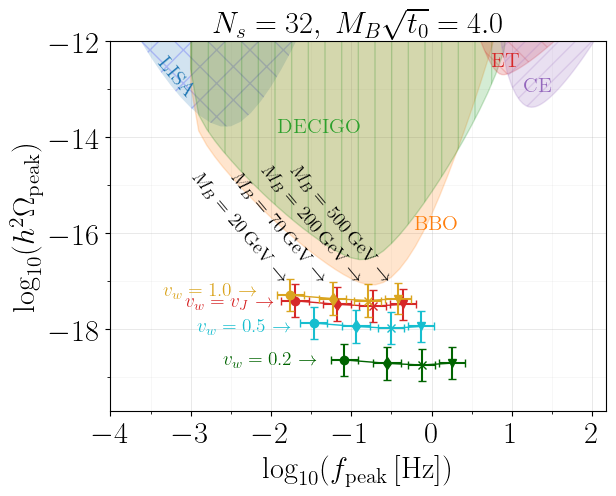

In [9]:
# ---- int switch: which fixed M_B\sqrt{t_0} to show (0:2.8, 1:3.2, 2:3.6, 3:4.0) ----
# Restyled to match the N_s / combined plots: log10 LINEAR axes, log10 axis labels, faint grid,
# N_s=32 title. v_w tracks + connecting lines + annotations kept (positions wrapped in log10).
imb = 3
MB_fixed = MB_vals[imb]

# vJ reuses the ORIGINAL fT_res_v2 color for this M_B sqrt t0 (colors[imb]);
# the imposed fixed-v_w cases are new points, so they take distinct colors.
vw_colors = [colors[imb], "goldenrod", "#17becf", "darkgreen"]  # vJ, 1.0, 0.5, 0.2
LN10 = np.log(10.0)

plt.clf()
fig = plt.figure()
ax = plt.axes()

# barely-visible grid (behind everything)
ax.set_axisbelow(True)
ax.grid(True, which='major', color='0.6', alpha=0.30, lw=0.5, zorder=0)
ax.grid(True, which='minor', color='0.8', alpha=0.25, lw=0.4, zorder=0)

# detector threshold bands: PLIS cols are ALREADY log10(f), log10(h^2 Omega) -> plot directly; fill up to 0
ax.fill_between(LISA[::500].T[0], LISA[::500].T[1], 0.0,
                color='C0', edgecolor='b', hatch='X', linewidth=0.0, alpha=0.2)
ax.fill_between(BBO[::400].T[0], BBO[::400].T[1], 0.0,
                color='C1', alpha=0.2)
ax.fill_between(DECIGO[::400].T[0], DECIGO[::400].T[1], 0.0,
                color='C2', edgecolor='g', hatch='|', alpha=0.2)
ax.fill_between(ET[0:160:2].T[0], ET[0:160:2].T[1], 0.0,
                color='C3', edgecolor='C3', hatch='\\', alpha=0.2)
ax.fill_between(CE[:400:5].T[0], CE[:400:5].T[1], 0.0,
                color='C4', edgecolor='C4', hatch='//', alpha=0.2)

# each v_w case (color) traces its 4 points (connecting line kept); marker encodes M_B [GeV]; log10 axes
vw_lines = []
for ivw in range(len(vw_results)):
    sub = vw_results[ivw][imb::4]
    shsub = sh_results[ivw][imb::4]
    lf = np.log10(sub.T[3])
    lo = np.log10(sub.T[4])
    line, = ax.plot(lf, lo, ls='-', lw=1.0, c=vw_colors[ivw], zorder=2)
    vw_lines.append(line)
    for k in range(len(sub)):
        ex = np.sqrt((sub[k][5] / (sub[k][3] * LN10))**2 + shsub[k][2]**2)  # stat (+) hist
        ey = np.sqrt((sub[k][6] / (sub[k][4] * LN10))**2 + shsub[k][3]**2)
        ax.errorbar(np.log10(sub[k][3]), np.log10(sub[k][4]), xerr=ex, yerr=ey,
                    ls='none', capsize=3, marker=markers[k], c=vw_colors[ivw], zorder=3)

ax.set_xlim(-4.0, np.log10(150))
ax.set_ylim(np.log10(2e-20), -12.0)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(2))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(fontsize=22)
plt.yticks(fontsize=22)
ax.set_xlabel("$\\log_{10}(f_{\\rm peak}\\,[{\\rm Hz}])$", fontsize=22)
ax.set_ylabel("$\\log_{10}(h^2\\Omega_{\\rm peak})$", fontsize=22)
ax.set_title("$N_s = 32, \\ M_B\\sqrt{t_0}=" + str(MB_fixed) + "$", fontsize=22)

# detector-band labels (positions wrapped in log10; rotations unchanged)
ax.text(np.log10(0.00035), np.log10(7.0e-14), "${\\rm LISA}$", fontsize=15, rotation=-50, color='C0')
ax.text(np.log10(0.6), np.log10(1.20e-16), "${\\rm BBO}$", fontsize=15, rotation=0, color='C1')
ax.text(np.log10(0.012), np.log10(125.0e-16), "${\\rm DECIGO}$", fontsize=15, rotation=0, color='C2')
ax.text(np.log10(5.5), np.log10(3.0e-13), "${\\rm ET}$", fontsize=15, rotation=0, color='C3')
ax.text(np.log10(14.0), np.log10(9.0e-14), "${\\rm CE}$", fontsize=15, rotation=0, color='C4')

# manual v_w annotations (each colored to its own track; positions wrapped in log10)
ax.text(np.log10(0.00045), np.log10(5.e-18), "$v_w=1.0 \\rightarrow$", fontsize=14, color=vw_colors[1])
ax.text(np.log10(0.00085), np.log10(3e-18), "$v_w=v_J \\rightarrow$", fontsize=14, color=vw_colors[0])
ax.text(np.log10(0.0012), np.log10(9e-19), "$v_w=0.5 \\rightarrow$", fontsize=14, color=vw_colors[2])
ax.text(np.log10(0.0025), np.log10(19.0e-20), "$v_w=0.2 \\rightarrow$", fontsize=14, color=vw_colors[3])

# manual M_B [GeV] annotations above each MBGeV cluster (positions wrapped in log10)
# ax.text(np.log10(0.0018 / 1.5), np.log10(2.8e-18), "$M_B=20 \\,{\\rm GeV} \\rightarrow$", fontsize=14, rotation=-50)
# ax.text(np.log10(0.0055 / 1.5), np.log10(2.8e-18), "$M_B=70 \\,{\\rm GeV} \\rightarrow$", fontsize=14, rotation=-50)
# ax.text(np.log10(0.017 / 1.8), np.log10(2.8e-18), "$M_B=200 \\,{\\rm GeV} \\rightarrow$", fontsize=14, rotation=-50)
# ax.text(np.log10(0.045 / 1.8), np.log10(2.8e-18), "$M_B=500 \\,{\\rm GeV} \\rightarrow$", fontsize=14, rotation=-50)
ax.text(np.log10(0.0014 / 1.5), np.log10(9.5e-18), "$M_B=20 \\,{\\rm GeV} \\rightarrow$", fontsize=14, rotation=-50)
ax.text(np.log10(0.0042 / 1.5), np.log10(9.5e-18), "$M_B=70 \\,{\\rm GeV} \\rightarrow$", fontsize=14, rotation=-50)
ax.text(np.log10(0.012 / 1.8), np.log10(9.5e-18), "$M_B=200 \\,{\\rm GeV} \\rightarrow$", fontsize=14, rotation=-50)
ax.text(np.log10(0.028 / 1.8), np.log10(9.5e-18), "$M_B=500 \\,{\\rm GeV} \\rightarrow$", fontsize=14, rotation=-50)

plt.savefig("sensitivity_vw_Ns32_c2only_MB" + str(MB_fixed) + "_stathist_claude.pdf", format='pdf', bbox_inches='tight')
plt.savefig("sensitivity_vw_Ns32_c2only_MB" + str(MB_fixed) + "_stathist_claude.png", format='png', dpi=150, bbox_inches='tight')
plt.show()